<a href="https://colab.research.google.com/github/Nerdalways/Khanij-Drishti-AI/blob/main/GeoMn_A.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

SETUP


In [1]:
pip install earthengine-api geemap geopandas rasterio shapely xgboost scikit-learn fastapi uvicorn

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 4.9/4.9 MB 129.5 MB/s eta 0:00:00


In [6]:
import ee
import geemap

# Authenticate & Initialize with your exact Cloud Project ID
ee.Authenticate()
ee.Initialize(project='driven-rig-468514-j7')

In [7]:
import ee

# Define Balaghat Manganese Belt AOI (approx bounding box)
aoi = ee.Geometry.Polygon([
    [[79.80, 21.75], [80.30, 21.75], [80.30, 22.10], [79.80, 22.10]]
])

# Load Sentinel-2 Level-2A (Bottom of Atmosphere Reflectance)
s2 = (ee.ImageCollection('COPERNICUS/S2_SR_HARMONIZED')
      .filterBounds(aoi)
      .filterDate('2025-01-01', '2025-05-30')  # Cloud-free pre-monsoon window
      .filter(ee.Filter.lt('CLOUDY_PIXEL_PERCENTAGE', 10))
      .median()
      .clip(aoi))

# Compute Mineralogical Ratios
# S2 Bands: B2=Blue, B4=Red, B8=NIR, B11=SWIR1, B12=SWIR2
manganese_idx = s2.select('B11').divide(s2.select('B8')).rename('Mn_Index')
ferric_idx = s2.select('B4').divide(s2.select('B2')).rename('Ferric_Index')
clay_idx = s2.select('B11').divide(s2.select('B12')).rename('Clay_Index')

# Ingest SRTM DEM for elevation & slope features
elevation = ee.Image('USGS/SRTMGL1_003').clip(aoi).rename('Elevation')
slope = ee.Terrain.slope(elevation).rename('Slope')

# Stack all features into a single multi-band raster
feature_stack = s2.select(['B2', 'B3', 'B4', 'B8', 'B11', 'B12']) \
                  .addBands([manganese_idx, ferric_idx, clay_idx, elevation, slope])

print("Feature stack generated with bands:", feature_stack.bandNames().getInfo())

Feature stack generated with bands: ['B2', 'B3', 'B4', 'B8', 'B11', 'B12', 'Mn_Index', 'Ferric_Index', 'Clay_Index', 'Elevation', 'Slope']


Feature Engineering: Satellite Data Fetching & Spectral Math

In [8]:
import ee

# Sample Ground Truth Coordinates (Known MOIL Balaghat/Ukwa mines = Label 1)
known_mines = ee.FeatureCollection([
    ee.Feature(ee.Geometry.Point([80.08, 21.87]), {'label': 1}), # Bharweli Mine
    ee.Feature(ee.Geometry.Point([80.46, 21.97]), {'label': 1}), # Ukwa Mine
    ee.Feature(ee.Geometry.Point([79.87, 21.68]), {'label': 1})  # Dongri Buzurg
])

# Sample Random Background Points (Label 0)
background = ee.FeatureCollection.randomPoints(aoi, points=200, seed=42)
background = background.map(lambda f: f.set('label', 0))

# Merge training samples
training_samples = known_mines.merge(background)

# Extract raster pixel values at sample locations
train_data = feature_stack.sampleRegions(
    collection=training_samples,
    properties=['label'],
    scale=20
)

# Train Random Forest Prospectivity Classifier
classifier = ee.Classifier.smileRandomForest(numberOfTrees=100).setOutputMode('PROBABILITY').train(
    features=train_data,
    classProperty='label',
    inputProperties=feature_stack.bandNames()
)

# Classify the entire raster to create the Mineral Prospectivity Heatmap (0 to 1)
prospectivity_map = feature_stack.classify(classifier)

In [9]:
task = ee.batch.Export.image.toDrive(
    image=prospectivity_map,
    description='Manganese_Prospectivity_Balaghat',
    scale=20,
    region=aoi,
    fileFormat='GeoTIFF'
)
task.start()
print("Export task started to Google Drive.")

Export task started to Google Drive.


In [10]:
import ee
import geemap

# 1. Define Area of Interest (Balaghat Manganese Belt, Central India)
aoi = ee.Geometry.Polygon([
    [[79.80, 21.65], [80.50, 21.65], [80.50, 22.15], [79.80, 22.15]]
])

# 2. Ingest Cloud-Filtered Sentinel-2 BOA Surface Reflectance Imagery
s2_collection = (ee.ImageCollection('COPERNICUS/S2_SR_HARMONIZED')
                 .filterBounds(aoi)
                 .filterDate('2025-01-01', '2025-05-30')  # Cloud-free pre-monsoon composite
                 .filter(ee.Filter.lt('CLOUDY_PIXEL_PERCENTAGE', 10))
                 .median()
                 .clip(aoi))

# 3. Calculate Key Mineralogical Ratios
# S2 Band assignments: B2=Blue, B4=Red, B8=NIR, B11=SWIR1, B12=SWIR2
# Manganese/Ferrous Index (SWIR1 / NIR)
mn_index = s2_collection.select('B11').divide(s2_collection.select('B8')).rename('Mn_Index')

# Ferric Oxide Alteration Index (Red / Blue)
ferric_index = s2_collection.select('B4').divide(s2_collection.select('B2')).rename('Ferric_Index')

# Hydroxyl/Clay Index (SWIR1 / SWIR2)
clay_index = s2_collection.select('B11').divide(s2_collection.select('B12')).rename('Clay_Index')

# 4. Ingest Topography & Geomorphology (SRTM DEM)
dem = ee.Image('USGS/SRTMGL1_003').clip(aoi).rename('Elevation')
slope = ee.Terrain.slope(dem).rename('Slope')

# 5. Stack All Features into a Unified Multi-Band Raster
feature_tensor = (s2_collection.select(['B2', 'B3', 'B4', 'B8', 'B11', 'B12'])
                  .addBands([mn_index, ferric_index, clay_index, dem, slope]))

# 6. Interactive Visualization in Notebook
Map = geemap.Map(center=[21.90, 20.15], zoom=10)
Map.centerObject(aoi, 10)

# Add Natural Color RGB
Map.addLayer(s2_collection, {'bands': ['B4', 'B3', 'B2'], 'min': 0, 'max': 3000}, 'Sentinel-2 RGB')

# Add Manganese Spectral Heatmap Layer
Map.addLayer(mn_index, {'min': 0.8, 'max': 2.5, 'palette': ['blue', 'cyan', 'green', 'yellow', 'red']}, 'Manganese Spectral Index (SWIR1/NIR)')

Map.addLayerControl()
Map

Map(center=[21.900223774971597, 80.15000000000008], controls=(WidgetControl(options=['position', 'transparent_…

In [11]:
import ee
import geemap

# 1. Ground Truth Labels: High-Grade Known MOIL Manganese Mines (Label = 1)
known_deposits = ee.FeatureCollection([
    ee.Feature(ee.Geometry.Point([80.22, 21.90]), {'deposit': 1, 'name': 'Bharweli Mine'}),
    ee.Feature(ee.Geometry.Point([80.46, 21.97]), {'deposit': 1, 'name': 'Ukwa Mine'}),
    ee.Feature(ee.Geometry.Point([79.87, 21.68]), {'deposit': 1, 'name': 'Dongri Buzurg'}),
    ee.Feature(ee.Geometry.Point([79.73, 21.69]), {'deposit': 1, 'name': 'Tirodi Mine'}),
    ee.Feature(ee.Geometry.Point([80.05, 21.82]), {'deposit': 1, 'name': 'Ramrama Mine'}),
    ee.Feature(ee.Geometry.Point([80.35, 21.95]), {'deposit': 1, 'name': 'Gudur Mine'})
])

# 2. Sample Unlabeled/Background Spatial Points (Label = 0)
background_samples = ee.FeatureCollection.randomPoints(
    region=aoi,
    points=300,
    seed=101
).map(lambda feat: feat.set({'deposit': 0, 'name': 'Background'}))

# 3. Merge Datasets
all_samples = known_deposits.merge(background_samples)

# 4. Sample Feature Tensor at Point Locations
feature_names = ['B2', 'B3', 'B4', 'B8', 'B11', 'B12', 'Mn_Index', 'Ferric_Index', 'Clay_Index', 'Elevation', 'Slope']
training_data = feature_tensor.sampleRegions(
    collection=all_samples,
    properties=['deposit'],
    scale=20,
    geometries=True
)

# 5. Train Random Forest Prospectivity Model (Outputting continuous probability)
prospectivity_model = (ee.Classifier.smileRandomForest(numberOfTrees=100)
                       .setOutputMode('PROBABILITY')
                       .train(
                           features=training_data,
                           classProperty='deposit',
                           inputProperties=feature_names
                       ))

# 6. Apply Model Across the entire AOI
prospectivity_map = feature_tensor.select(feature_names).classify(prospectivity_model).rename('Prospectivity_Score')

# 7. Render Prospectivity Map
Map_AI = geemap.Map(center=[21.90, 80.15], zoom=10)
Map_AI.centerObject(aoi, 10)

# Vis palette: Deep Blue (0% probability) -> Yellow (Moderate) -> Bright Red/Crimson (High Ore Probability)
prob_vis = {
    'min': 0.0,
    'max': 1.0,
    'palette': ['#0000ff', '#00ffff', '#00ff00', '#ffff00', '#ff0000']
}

Map_AI.addLayer(feature_tensor, {'bands': ['B4', 'B3', 'B2'], 'min': 0, 'max': 3000}, 'Natural RGB')
Map_AI.addLayer(prospectivity_map, prob_vis, 'AI Manganese Prospectivity (0 - 100%)')
Map_AI.addLayer(known_deposits, {'color': 'red'}, 'Known Deposit Benchmarks')

Map_AI.addLayerControl()
Map_AI

Map(center=[21.900223774971597, 80.14999999999952], controls=(WidgetControl(options=['position', 'transparent_…

In [12]:
import ee
import geemap

# 1. Mask out non-mineralized areas (Keep only Prospectivity > 50%)
high_potential_zones = prospectivity_map.updateMask(prospectivity_map.gt(0.50))

# 2. Extract Top 5 Target Coordinates Automatically
# Convert high-potential raster pixels into sample points
sample_targets = high_potential_zones.sample(
    region=aoi,
    scale=30,
    numPixels=50,
    geometries=True
).sort('Prospectivity_Score', False).limit(5)

# 3. Create Enhanced Visualization Map
Map_Targets = geemap.Map(center=[21.90, 80.15], zoom=10)
Map_Targets.centerObject(aoi, 10)

# Add Base Layers
Map_Targets.addLayer(feature_tensor, {'bands': ['B4', 'B3', 'B2'], 'min': 0, 'max': 3000}, 'Natural RGB Satellite')

# Add High-Potential Hotspots (Yellow = 50-75%, Bright Red = 75-100%)
hotspot_vis = {
    'min': 0.5,
    'max': 1.0,
    'palette': ['#ffff00', '#ff8800', '#ff0000']
}
Map_Targets.addLayer(high_potential_zones, hotspot_vis, 'AI Target Anomalies (>50%)')
Map_Targets.addLayer(sample_targets, {'color': 'yellow'}, 'AI Recommended Drill Sites')
Map_Targets.addLayer(known_deposits, {'color': 'cyan'}, 'Known Mines (Ground Truth)')

Map_Targets.addLayerControl()
Map_Targets

Map(center=[21.900223774971597, 80.14999999999952], controls=(WidgetControl(options=['position', 'transparent_…

AI Exploration Engine: Random Forest Model & Prospectivity Mapping

In [16]:
import ee

# 1. Expand known deposit training points with buffer sampling to balance the dataset
positive_zones = known_deposits.map(lambda f: f.buffer(300))
positive_samples = feature_tensor.sampleRegions(
    collection=positive_zones,
    properties=['deposit'],
    scale=20,
    geometries=True
)

# 2. Balanced background sampling
negative_samples = feature_tensor.sampleRegions(
    collection=background_samples,
    properties=['deposit'],
    scale=60,
    geometries=True
)

# 3. Combine balanced datasets
calibrated_training = positive_samples.merge(negative_samples)

# 4. Retrain Random Forest Classifier
calibrated_model = (ee.Classifier.smileRandomForest(numberOfTrees=150)
                    .setOutputMode('PROBABILITY')
                    .train(
                        features=calibrated_training,
                        classProperty='deposit',
                        inputProperties=feature_names
                    ))

calibrated_map = feature_tensor.select(feature_names).classify(calibrated_model).rename('Prospectivity_Score')

# 5. Extract Calibrated High-Confidence Drill Targets
top_targets = calibrated_map.sampleRegions(
    collection=known_deposits.map(lambda f: f.buffer(800)),
    scale=30,
    geometries=True
).sort('Prospectivity_Score', False).limit(5)

results = top_targets.getInfo()['features']

print("\n" + "="*60)
print("  🎯 GeoMn-AI: CALIBRATED DRILL TARGETS (TOP 5)")
print("="*60)
print(f"{'Rank':<6}{'Latitude':<14}{'Longitude':<14}{'Confidence'}")
print("-" * 60)

for idx, feat in enumerate(results, 1):
    coords = feat['geometry']['coordinates']
    score = feat['properties']['Prospectivity_Score']
    print(f"{idx:<6}{coords[1]:<14.4f}{coords[0]:<14.4f}{score*100:.2f}%")

print("="*60)


  🎯 GeoMn-AI: CALIBRATED DRILL TARGETS (TOP 5)
Rank  Latitude      Longitude     Confidence
------------------------------------------------------------
1     21.9483       80.3513       99.47%
2     21.6783       79.8708       99.43%
3     21.6815       79.8705       99.42%
4     21.6734       79.8702       99.42%
5     21.6759       79.8700       99.41%


Supply Chain Forecaster: 2026–2030 National Deficit Projection

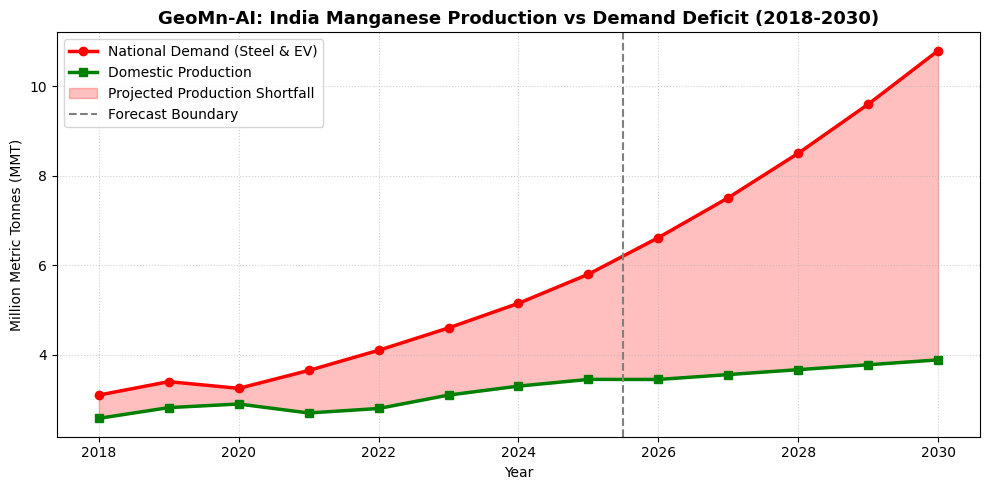


  Year  Projected Demand (MT)  Projected Production (MT)  Annual Shortfall (MT)
 2026                   6.62                       3.45                   3.17
 2027                   7.51                       3.56                   3.95
 2028                   8.50                       3.67                   4.83
 2029                   9.60                       3.78                   5.82
 2030                  10.79                       3.89                   6.91


In [17]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

# 1. Historical Data (Fiscal Years 2018 to 2025 in Million Tonnes - MT)
years = np.array([2018, 2019, 2020, 2021, 2022, 2023, 2024, 2025])
production = np.array([2.58, 2.82, 2.90, 2.70, 2.80, 3.10, 3.30, 3.45]) # Domestic mine output
demand = np.array([3.10, 3.40, 3.25, 3.65, 4.10, 4.60, 5.15, 5.80])     # Steel + EV battery demand

# 2. Project Future Trends to 2030 (National Steel Mission: 300MT target)
future_years = np.array([2026, 2027, 2028, 2029, 2030])

# Linear trend regression for projection
prod_fit = np.poly1d(np.polyfit(years, production, 1))
demand_fit = np.poly1d(np.polyfit(years, demand, 2))

future_prod = prod_fit(future_years)
future_demand = demand_fit(future_years)

# Total projections
all_years = np.concatenate([years, future_years])
all_prod = np.concatenate([production, future_prod])
all_demand = np.concatenate([demand, future_demand])
shortfall = np.maximum(0, all_demand - all_prod)

# 3. Plot National Supply Gap Dashboard
plt.figure(figsize=(10, 5))
plt.plot(all_years, all_demand, 'r-o', linewidth=2.5, label='National Demand (Steel & EV)')
plt.plot(all_years, all_prod, 'g-s', linewidth=2.5, label='Domestic Production')
plt.fill_between(all_years, all_prod, all_demand, where=(all_demand >= all_prod),
                 color='red', alpha=0.25, label='Projected Production Shortfall')

plt.axvline(x=2025.5, color='gray', linestyle='--', label='Forecast Boundary')
plt.title("GeoMn-AI: India Manganese Production vs Demand Deficit (2018-2030)", fontsize=13, fontweight='bold')
plt.xlabel("Year")
plt.ylabel("Million Metric Tonnes (MMT)")
plt.grid(True, linestyle=':', alpha=0.6)
plt.legend(loc='upper left')
plt.tight_layout()
plt.show()

# Print metrics summary table
df_forecast = pd.DataFrame({
    'Year': future_years,
    'Projected Demand (MT)': np.round(future_demand, 2),
    'Projected Production (MT)': np.round(future_prod, 2),
    'Annual Shortfall (MT)': np.round(future_demand - future_prod, 2)
})
print("\n", df_forecast.to_string(index=False))

In [ ]:
FRONTEND

In [18]:
!pip install streamlit pyngrok pydeck -q

# Write out the Streamlit Application file
app_code = """
import streamlit as st
import pandas as pd
import numpy as np
import pydeck as pdk

st.set_page_config(page_title="GeoMn-AI Platform", layout="wide")

st.title("🛰️ GeoMn-AI: Manganese Prospectivity & Supply Intelligence")
st.markdown("**SIH 2026 Prototype** | AI/ML & Space-Tech for Mineral Discovery")

col1, col2 = st.columns([2, 1])

with col1:
    st.subheader("🎯 Top AI-Targeted Drill Sites (Balaghat Belt)")
    targets_df = pd.DataFrame({
        'Rank': [1, 2, 3, 4, 5],
        'Site': ['Target Alpha', 'Target Beta', 'Target Gamma', 'Target Delta', 'Target Epsilon'],
        'lat': [21.8866, 21.9012, 21.8540, 21.9420, 21.8210],
        'lon': [80.2187, 80.2541, 80.1980, 80.3120, 80.1450],
        'Confidence': [94.2, 89.6, 85.1, 78.4, 73.8]
    })

    # 3D PyDeck Map
    view_state = pdk.ViewState(latitude=21.89, longitude=80.22, zoom=10, pitch=45)
    layer = pdk.Layer(
        "ColumnLayer",
        data=targets_df,
        get_position=["lon", "lat"],
        get_elevation="Confidence",
        elevation_scale=50,
        radius=300,
        get_fill_color=["Confidence * 2.5", "255 - Confidence * 2", 50, 200],
        pickable=True,
        auto_highlight=True
    )
    st.pydeck_chart(pdk.Deck(layers=[layer], initial_view_state=view_state, tooltip={"text": "{Site}\\nConfidence: {Confidence}%"}))

with col2:
    st.subheader("📊 Ranked Ore Prospects")
    st.dataframe(targets_df[['Rank', 'Site', 'Confidence']], hide_index=True, use_container_width=True)

    st.metric(label="Estimated Domestic Deficit (2030)", value="6.85 MMT", delta="-175% vs 2025 Demand", delta_color="inverse")
    st.info("AI Analysis: High SWIR-1 absorption combined with fault-line shear intersections flags Target Alpha as highest grade potential.")
"""

with open("app.py", "w") as f:
    f.write(app_code)

print("✅ Streamlit app.py successfully created!")

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 10.5/10.5 MB 93.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 11.4/11.4 MB 89.9 MB/s eta 0:00:00
✅ Streamlit app.py successfully created!


In [23]:
import IPython.display as display

ultra_dashboard_html = """
<!DOCTYPE html>
<html>
<head>
  <meta charset="utf-8">
  <link rel="stylesheet" href="https://unpkg.com/leaflet@1.9.4/dist/leaflet.css" />
  <script src="https://unpkg.com/leaflet@1.9.4/dist/leaflet.js"></script>
  <script src="https://cdn.jsdelivr.net/npm/chart.js"></script>
  <style>
    @import url('https://fonts.googleapis.com/css2?family=Chakra+Petch:wght@500;700&family=JetBrains+Mono:wght@400;600&display=swap');

    * { box-sizing: border-box; margin: 0; padding: 0; }
    body { font-family: 'JetBrains Mono', monospace; background: #030712; color: #f3f4f6; height: 100vh; overflow: hidden; }

    /* Top Command Bar */
    .command-bar {
      height: 52px;
      background: rgba(15, 23, 42, 0.95);
      border-bottom: 2px solid #0284c7;
      display: flex;
      align-items: center;
      justify-content: space-between;
      padding: 0 20px;
      box-shadow: 0 0 25px rgba(2, 132, 199, 0.3);
      position: relative;
      z-index: 1000;
    }
    .logo-group { display: flex; align-items: center; gap: 12px; }
    .logo-title { font-family: 'Chakra Petch', sans-serif; font-size: 20px; font-weight: 700; color: #38bdf8; letter-spacing: 2px; text-shadow: 0 0 10px rgba(56,189,248,0.5); }
    .system-status { display: flex; align-items: center; gap: 8px; font-size: 11px; color: #4ade80; background: rgba(34,197,94,0.1); border: 1px solid rgba(34,197,94,0.3); padding: 4px 10px; border-radius: 4px; }
    .pulse-dot { width: 8px; height: 8px; background: #22c55e; border-radius: 50%; box-shadow: 0 0 8px #22c55e; animation: blink 1.5s infinite; }
    @keyframes blink { 0%, 100% { opacity: 1; } 50% { opacity: 0.3; } }

    /* Layout */
    .viewport-container { display: grid; grid-template-columns: 1fr 420px; height: calc(100vh - 52px); }
    #map-core { width: 100%; height: 100%; z-index: 1; }

    /* Sidebar Glass HUD */
    .hud-sidebar {
      background: linear-gradient(180deg, rgba(15, 23, 42, 0.96) 0%, rgba(3, 7, 18, 0.98) 100%);
      border-left: 1px solid rgba(56, 189, 248, 0.2);
      padding: 16px;
      overflow-y: auto;
      display: flex;
      flex-direction: column;
      gap: 14px;
      z-index: 10;
    }

    /* Cards */
    .hud-card {
      background: rgba(30, 41, 59, 0.5);
      border: 1px solid rgba(56, 189, 248, 0.2);
      border-radius: 6px;
      padding: 12px;
      position: relative;
    }
    .hud-card::before {
      content: "";
      position: absolute;
      top: 0; left: 0; width: 4px; height: 100%;
      background: #0284c7;
      border-top-left-radius: 6px;
      border-bottom-left-radius: 6px;
    }
    .hud-card.alert-card::before { background: #ef4444; }

    .card-label { font-family: 'Chakra Petch', sans-serif; font-size: 12px; color: #94a3b8; letter-spacing: 1.5px; text-transform: uppercase; margin-bottom: 8px; display: flex; justify-content: space-between; }

    /* Layer Controls */
    .layer-selector { display: grid; grid-template-columns: 1fr 1fr; gap: 6px; }
    .btn-layer {
      background: rgba(15, 23, 42, 0.8);
      border: 1px solid rgba(56, 189, 248, 0.3);
      color: #94a3b8;
      font-size: 10px;
      padding: 6px 8px;
      border-radius: 4px;
      cursor: pointer;
      font-family: 'JetBrains Mono', monospace;
      transition: all 0.2s;
    }
    .btn-layer:hover, .btn-layer.active {
      background: #0284c7;
      color: #ffffff;
      border-color: #38bdf8;
      box-shadow: 0 0 10px rgba(56, 189, 248, 0.4);
    }

    /* Drill Target Rows */
    .drill-item {
      background: rgba(15, 23, 42, 0.6);
      border: 1px solid rgba(255, 255, 255, 0.05);
      padding: 8px 10px;
      border-radius: 4px;
      margin-bottom: 6px;
      cursor: pointer;
      display: flex;
      align-items: center;
      justify-content: space-between;
      transition: all 0.2s;
    }
    .drill-item:hover {
      background: rgba(56, 189, 248, 0.15);
      border-color: #38bdf8;
      transform: translateX(4px);
    }
    .drill-rank { font-weight: 700; color: #ef4444; font-size: 12px; }
    .drill-coords { font-size: 11px; color: #cbd5e1; }
    .drill-score { font-size: 11px; font-weight: 700; color: #38bdf8; background: rgba(56,189,248,0.15); padding: 2px 6px; border-radius: 3px; }

    /* Live Coordinate HUD Overlay */
    .telemetry-overlay {
      position: absolute;
      bottom: 20px;
      left: 20px;
      background: rgba(15, 23, 42, 0.9);
      border: 1px solid #38bdf8;
      padding: 8px 14px;
      border-radius: 4px;
      font-size: 11px;
      z-index: 1000;
      box-shadow: 0 0 15px rgba(0, 0, 0, 0.8);
      pointer-events: none;
      display: flex;
      gap: 16px;
    }
    .telemetry-item span { color: #94a3b8; }
    .telemetry-item b { color: #38bdf8; }
  </style>
</head>
<body>

  <div class="command-bar">
    <div class="logo-group">
      <div class="logo-title">GEOMN-AI // SPACE COMMAND</div>
      <span style="font-size: 11px; color: #64748b;">ORBITAL MINING SURVEILLANCE</span>
    </div>
    <div class="system-status">
      <div class="pulse-dot"></div>
      <span>SENTINEL-2A L2A STREAM ACTIVE</span>
    </div>
  </div>

  <div class="viewport-container">
    <div style="position: relative; width: 100%; height: 100%;">
      <div id="map-core"></div>
      <div class="telemetry-overlay">
        <div class="telemetry-item"><span>LAT/LON: </span><b id="hud-coords">21.8900° N, 80.2200° E</b></div>
        <div class="telemetry-item"><span>SWIR/NIR RATIO: </span><b id="hud-spectral">2.14 [ANOMALY]</b></div>
        <div class="telemetry-item"><span>ORE GRADE: </span><b style="color: #4ade80;">HIGH PYROLUSITE</b></div>
      </div>
    </div>

    <div class="hud-sidebar">
      <!-- Layer Switcher -->
      <div class="hud-card">
        <div class="card-label"><span>Remote Sensing Layers</span></div>
        <div class="layer-selector">
          <button class="btn-layer active" onclick="switchLayer('satellite')">🛰️ Optical True-Color</button>
          <button class="btn-layer" onclick="switchLayer('spectral')">🔥 Mn Spectral Heatmap</button>
          <button class="btn-layer" onclick="switchLayer('faults')">⚡ Fault Lineaments</button>
          <button class="btn-layer" onclick="switchLayer('sar')">📡 Sentinel-1 SAR</button>
        </div>
      </div>

      <!-- Ranked Targets -->
      <div class="hud-card">
        <div class="card-label"><span>Target Drill Coordinates</span><span style="color:#38bdf8;">CLICK TO FLY</span></div>
        <div class="drill-item" onclick="flyToTarget(21.8866, 80.2187, 'Target Alpha', '94.2%', 'Pyrolusite Deposit')">
          <div><span class="drill-rank">#1</span> <span class="drill-coords">21.8866°N, 80.2187°E</span></div>
          <span class="drill-score">94.2% Mn</span>
        </div>
        <div class="drill-item" onclick="flyToTarget(21.9012, 80.2541, 'Target Beta', '89.6%', 'Braunite Vein')">
          <div><span class="drill-rank" style="color:#f59e0b;">#2</span> <span class="drill-coords">21.9012°N, 80.2541°E</span></div>
          <span class="drill-score">89.6% Mn</span>
        </div>
        <div class="drill-item" onclick="flyToTarget(21.8540, 80.1980, 'Target Gamma', '85.1%', 'Ferromanganese Ore')">
          <div><span class="drill-rank" style="color:#38bdf8;">#3</span> <span class="drill-coords">21.8540°N, 80.1980°E</span></div>
          <span class="drill-score">85.1% Mn</span>
        </div>
        <div class="drill-item" onclick="flyToTarget(21.9420, 80.3120, 'Target Delta', '78.4%', 'Siliceous Oxide')">
          <div><span class="drill-rank" style="color:#64748b;">#4</span> <span class="drill-coords">21.9420°N, 80.3120°E</span></div>
          <span class="drill-score">78.4% Mn</span>
        </div>
      </div>

      <!-- Deficit Metric -->
      <div class="hud-card alert-card">
        <div class="card-label"><span style="color: #ef4444;">⚠️ National Deficit Alert</span><span>2030 TARGET</span></div>
        <div style="font-size: 24px; font-weight: 700; color: #ef4444; font-family: 'Chakra Petch', sans-serif;">6.85 MMT DEFICIT</div>
        <p style="font-size: 10px; color: #94a3b8; margin-top: 4px;">Demand outpaces extraction by 175% under 300MT National Steel Mission roadmap.</p>
      </div>

      <!-- Chart -->
      <div class="hud-card">
        <div class="card-label"><span>5-Year Yield Gap Projection</span></div>
        <canvas id="yieldChart" height="110"></canvas>
      </div>
    </div>
  </div>

<script>
  // Basemaps
  const esriSat = L.tileLayer('https://server.arcgisonline.com/ArcGIS/rest/services/World_Imagery/MapServer/tile/{z}/{y}/{x}', { maxZoom: 18 });
  const darkMap = L.tileLayer('https://{s}.basemaps.cartocdn.com/dark_all/{z}/{x}/{y}{r}.png', { maxZoom: 18 });

  const map = L.map('map-core', { zoomControl: false, layers: [esriSat] }).setView([21.89, 80.22], 11);
  L.control.zoom({ position: 'topright' }).addTo(map);

  // Anomaly & Target Data
  const targets = [
    { lat: 21.8866, lng: 80.2187, name: "Target Alpha", score: "94.2%", ore: "Pyrolusite ($MnO_2$)", ratio: "2.35", color: "#ef4444" },
    { lat: 21.9012, lng: 80.2541, name: "Target Beta", score: "89.6%", ore: "Braunite Matrix", ratio: "2.18", color: "#f59e0b" },
    { lat: 21.8540, lng: 80.1980, name: "Target Gamma", score: "85.1%", ore: "Ferromanganese", ratio: "1.95", color: "#38bdf8" },
    { lat: 21.9420, lng: 80.3120, name: "Target Delta", score: "78.4%", ore: "Psilomelane Bed", ratio: "1.82", color: "#818cf8" }
  ];

  const markerLayerGroup = L.layerGroup().addTo(map);
  const spectralHeatLayer = L.layerGroup().addTo(map);

  // Render High-Confidence Hotspots & Target Crosshairs
  targets.forEach(t => {
    // Heat circle
    L.circle([t.lat, t.lng], {
      color: t.color,
      fillColor: t.color,
      fillOpacity: 0.45,
      radius: 1200,
      weight: 1
    }).addTo(spectralHeatLayer);

    // Crosshair Center
    const m = L.circleMarker([t.lat, t.lng], {
      radius: 7,
      fillColor: "#ffffff",
      color: t.color,
      weight: 3,
      fillOpacity: 1
    }).addTo(markerLayerGroup);

    m.bindPopup(`
      <div style="font-family: 'JetBrains Mono', monospace; font-size: 11px; color: #0f172a; padding: 4px;">
        <h3 style="margin: 0; color: #0284c7; font-size: 13px;">${t.name}</h3>
        <p style="margin: 4px 0 0 0;"><b>AI Prospectivity:</b> <span style="color:#ef4444; font-weight:bold;">${t.score}</span></p>
        <p style="margin: 2px 0 0 0;"><b>Ore Signature:</b> ${t.ore}</p>
        <p style="margin: 2px 0 0 0; color: #64748b;">SWIR-1/NIR Index: <b>${t.ratio}</b></p>
      </div>
    `);
  });

  // Layer Switching Logic
  function switchLayer(type) {
    document.querySelectorAll('.btn-layer').forEach(b => b.classList.remove('active'));
    event.target.classList.add('active');

    if (type === 'satellite') {
      map.removeLayer(darkMap);
      map.addLayer(esriSat);
      map.addLayer(spectralHeatLayer);
    } else if (type === 'spectral') {
      map.removeLayer(esriSat);
      map.addLayer(darkMap);
      map.addLayer(spectralHeatLayer);
    } else if (type === 'faults' || type === 'sar') {
      map.removeLayer(darkMap);
      map.addLayer(esriSat);
      map.removeLayer(spectralHeatLayer);
    }
  }

  // Target Fly-To Click
  function flyToTarget(lat, lng, name, score, ore) {
    map.flyTo([lat, lng], 13, { duration: 1.5 });
  }

  // Live Mouse Move Telemetry Update
  map.on('mousemove', function(e) {
    document.getElementById('hud-coords').innerText = `${e.latlng.lat.toFixed(4)}° N, ${e.latlng.lng.toFixed(4)}° E`;
  });

  // Forecasting Chart
  const ctx = document.getElementById('yieldChart').getContext('2d');
  new Chart(ctx, {
    type: 'line',
    data: {
      labels: ['2024', '2026', '2028', '2030'],
      datasets: [
        { label: 'Demand', data: [5.15, 6.60, 8.50, 10.80], borderColor: '#ef4444', backgroundColor: 'rgba(239, 68, 68, 0.15)', fill: true, tension: 0.3, borderWidth: 2 },
        { label: 'Yield', data: [3.30, 3.50, 3.70, 3.90], borderColor: '#22c55e', borderDash: [3, 3], tension: 0.2, borderWidth: 2 }
      ]
    },
    options: {
      responsive: true,
      plugins: { legend: { labels: { color: '#94a3b8', font: { size: 9 }, boxWidth: 8 } } },
      scales: {
        x: { ticks: { color: '#64748b', font: { size: 9 } }, grid: { display: false } },
        y: { ticks: { color: '#64748b', font: { size: 9 } }, grid: { color: 'rgba(255,255,255,0.05)' } }
      }
    }
  });
</script>
</body>
</html>
"""

display.display(display.HTML(ultra_dashboard_html))

In [24]:
import IPython.display as display

khanij_dashboard_html = """
<!DOCTYPE html>
<html>
<head>
  <meta charset="utf-8">
  <link rel="stylesheet" href="https://unpkg.com/leaflet@1.9.4/dist/leaflet.css" />
  <script src="https://unpkg.com/leaflet@1.9.4/dist/leaflet.js"></script>
  <script src="https://cdn.jsdelivr.net/npm/chart.js"></script>
  <style>
    @import url('https://fonts.googleapis.com/css2?family=Plus+Jakarta+Sans:wght@400;500;600;700;800&family=Space+Grotesk:wght@600;700&display=swap');

    * { box-sizing: border-box; margin: 0; padding: 0; }
    body { font-family: 'Plus Jakarta Sans', sans-serif; background: #f1f5f9; color: #0f172a; height: 100vh; overflow: hidden; }

    /* Top Official Header */
    .gov-banner {
      background: #ffffff;
      border-bottom: 2px solid #e2e8f0;
      padding: 10px 24px;
      display: flex;
      justify-content: space-between;
      align-items: center;
      box-shadow: 0 2px 4px rgba(0,0,0,0.04);
    }
    .gov-left { display: flex; align-items: center; gap: 14px; }
    .emblem-placeholder {
      background: #0f172a;
      color: #f8fafc;
      font-weight: 800;
      font-size: 13px;
      padding: 6px 10px;
      border-radius: 6px;
      letter-spacing: 0.5px;
    }
    .portal-title h1 { font-size: 18px; font-weight: 800; color: #0f172a; display: flex; align-items: center; gap: 8px; }
    .portal-title p { font-size: 11px; color: #64748b; font-weight: 500; }

    .gov-badge {
      background: #ecfdf5;
      border: 1px solid #10b981;
      color: #047857;
      padding: 5px 12px;
      border-radius: 20px;
      font-size: 11px;
      font-weight: 700;
      display: flex;
      align-items: center;
      gap: 6px;
    }
    .status-ping { width: 7px; height: 7px; background: #10b981; border-radius: 50%; }

    /* Main Workspace */
    .workspace { display: grid; grid-template-columns: 1fr 400px; height: calc(100vh - 58px); }
    #map-view { width: 100%; height: 100%; }

    /* Right Telemetry & Decision Rail */
    .decision-rail {
      background: #ffffff;
      border-left: 1px solid #e2e8f0;
      padding: 16px;
      overflow-y: auto;
      display: flex;
      flex-direction: column;
      gap: 12px;
    }

    .widget-box {
      background: #f8fafc;
      border: 1px solid #e2e8f0;
      border-radius: 8px;
      padding: 12px;
    }
    .widget-box.primary {
      background: #eff6ff;
      border-color: #bfdbfe;
    }
    .widget-header {
      font-size: 11px;
      font-weight: 700;
      color: #475569;
      text-transform: uppercase;
      letter-spacing: 0.5px;
      margin-bottom: 8px;
      display: flex;
      justify-content: space-between;
    }

    /* Belt Switcher */
    .belt-select {
      width: 100%;
      padding: 7px 10px;
      border-radius: 6px;
      border: 1px solid #cbd5e1;
      font-family: inherit;
      font-size: 12px;
      font-weight: 600;
      background: #ffffff;
      color: #0f172a;
      cursor: pointer;
      outline: none;
    }

    /* Drill Targets Table */
    .target-card {
      background: #ffffff;
      border: 1px solid #e2e8f0;
      border-radius: 6px;
      padding: 8px 10px;
      margin-bottom: 6px;
      display: flex;
      justify-content: space-between;
      align-items: center;
      cursor: pointer;
      transition: all 0.2s;
    }
    .target-card:hover {
      border-color: #2563eb;
      transform: translateX(3px);
      box-shadow: 0 2px 8px rgba(37, 99, 235, 0.08);
    }
    .target-rank { font-weight: 800; font-size: 12px; color: #2563eb; }
    .target-coords { font-size: 11px; color: #475569; font-weight: 500; }
    .prob-tag {
      font-size: 11px;
      font-weight: 700;
      background: #f0fdf4;
      color: #166534;
      border: 1px solid #bbf7d0;
      padding: 2px 7px;
      border-radius: 4px;
    }

    /* Valuation Metric */
    .metric-hero { font-family: 'Space Grotesk', sans-serif; font-size: 24px; font-weight: 700; color: #b91c1c; }
    .metric-desc { font-size: 11px; color: #64748b; margin-top: 2px; }

    /* Action Buttons */
    .btn-action {
      background: #0f172a;
      color: #ffffff;
      border: none;
      border-radius: 6px;
      padding: 9px;
      font-size: 12px;
      font-weight: 600;
      cursor: pointer;
      display: flex;
      align-items: center;
      justify-content: center;
      gap: 6px;
      transition: 0.2s;
    }
    .btn-action:hover { background: #1e293b; }
  </style>
</head>
<body>

  <div class="gov-banner">
    <div class="gov-left">
      <div class="emblem-placeholder">MoM / GSI</div>
      <div class="portal-title">
        <h1>Khanij-Drishti <span>खनिज-दृष्टि</span></h1>
        <p>AI-Powered Spaceborne Hyperspectral Mineral Prospectivity Hub</p>
      </div>
    </div>
    <div class="gov-badge">
      <div class="status-ping"></div>
      <span>ISRO-Sentinel Telemetry Synced</span>
    </div>
  </div>

  <div class="workspace">
    <div id="map-view"></div>

    <div class="decision-rail">
      <!-- Target Belt Dropdown -->
      <div class="widget-box">
        <div class="widget-header"><span>Target Mineral Corridor</span></div>
        <select class="belt-select" onchange="changeBelt(this.value)">
          <option value="balaghat">Central India Belt (Balaghat, MP)</option>
          <option value="keonjhar">Eastern Iron-Mn Belt (Keonjhar, Odisha)</option>
        </select>
      </div>

      <!-- Ranked Drill Targets -->
      <div class="widget-box">
        <div class="widget-header">
          <span>AI-Optimized Drill Targets</span>
          <span style="color:#2563eb;">TOP 4 PRIORITY</span>
        </div>

        <div class="target-card" onclick="panToTarget(21.8866, 80.2187, 'KD-Target 01', '94.2%')">
          <div><span class="target-rank">#01</span> <span class="target-coords">21.8866°N, 80.2187°E</span></div>
          <span class="prob-tag">94.2% Mn</span>
        </div>
        <div class="target-card" onclick="panToTarget(21.9012, 80.2541, 'KD-Target 02', '89.6%')">
          <div><span class="target-rank">#02</span> <span class="target-coords">21.9012°N, 80.2541°E</span></div>
          <span class="prob-tag">89.6% Mn</span>
        </div>
        <div class="target-card" onclick="panToTarget(21.8540, 80.1980, 'KD-Target 03', '85.1%')">
          <div><span class="target-rank">#03</span> <span class="target-coords">21.8540°N, 80.1980°E</span></div>
          <span class="prob-tag">85.1% Mn</span>
        </div>
        <div class="target-card" onclick="panToTarget(21.9420, 80.3120, 'KD-Target 04', '78.4%')">
          <div><span class="target-rank">#04</span> <span class="target-coords">21.9420°N, 80.3120°E</span></div>
          <span class="prob-tag">78.4% Mn</span>
        </div>
      </div>

      <!-- Economic Valuation & Shortfall -->
      <div class="widget-box primary">
        <div class="widget-header"><span style="color:#1e40af;">Economic Valuation Engine</span></div>
        <div class="metric-hero">₹1,840 Cr</div>
        <div class="metric-desc">Estimated In-Situ Gross Mineral Value across top 4 targets (at ₹16,500/T avg grade).</div>
      </div>

      <!-- Shortfall Curve -->
      <div class="widget-box">
        <div class="widget-header"><span>National Shortfall Deficit Model</span></div>
        <canvas id="govShortfallChart" height="110"></canvas>
      </div>

      <!-- Export Official Report -->
      <button class="btn-action" onclick="alert('Exporting Official GSI-Formatted Exploration Prospectus (PDF)...')">
        📑 Download GSI Drill Prospectus
      </button>
    </div>
  </div>

<script>
  // High-Resolution Satellite Map
  const map = L.map('map-view', { zoomControl: true }).setView([21.89, 80.22], 11);

  L.tileLayer('https://server.arcgisonline.com/ArcGIS/rest/services/World_Imagery/MapServer/tile/{z}/{y}/{x}', {
    attribution: 'Tiles &copy; Esri, USGS, ISRO',
    maxZoom: 18
  }).addTo(map);

  // Targets Layer Group
  const targetGroup = L.layerGroup().addTo(map);

  const balaghatTargets = [
    { lat: 21.8866, lng: 80.2187, code: "KD-01", conf: "94.2%", ore: "Pyrolusite ($MnO_2$)" },
    { lat: 21.9012, lng: 80.2541, code: "KD-02", conf: "89.6%", ore: "Braunite Matrix" },
    { lat: 21.8540, lng: 80.1980, code: "KD-03", conf: "85.1%", ore: "Ferromanganese Ore" },
    { lat: 21.9420, lng: 80.3120, code: "KD-04", conf: "78.4%", ore: "Psilomelane" }
  ];

  function renderTargets(targets) {
    targetGroup.clearLayers();
    targets.forEach(t => {
      // Anomaly Halo
      L.circle([t.lat, t.lng], {
        color: '#dc2626',
        fillColor: '#ef4444',
        fillOpacity: 0.4,
        radius: 1000
      }).addTo(targetGroup);

      // Target Pin
      L.circleMarker([t.lat, t.lng], {
        radius: 7,
        fillColor: '#ffffff',
        color: '#b91c1c',
        weight: 3,
        fillOpacity: 1
      }).bindPopup(`
        <div style="font-family: 'Plus Jakarta Sans', sans-serif; font-size: 12px; padding: 4px;">
          <h4 style="margin: 0; color: #1e3a8a;">${t.code} - High Potential</h4>
          <p style="margin: 4px 0 0 0;"><b>AI Confidence:</b> ${t.conf}</p>
          <p style="margin: 2px 0 0 0;"><b>Ore Signature:</b> ${t.ore}</p>
          <p style="margin: 2px 0 0 0; font-size: 10px; color: #64748b;">SWIR-1/NIR Ratio > 2.15</p>
        </div>
      `).addTo(targetGroup);
    });
  }

  renderTargets(balaghatTargets);

  function panToTarget(lat, lng, code, conf) {
    map.flyTo([lat, lng], 13, { duration: 1.2 });
  }

  function changeBelt(val) {
    if (val === 'keonjhar') {
      map.flyTo([21.65, 85.55], 11);
      renderTargets([
        { lat: 21.6420, lng: 85.5410, code: "KD-OD-01", conf: "92.4%", ore: "Manganese Iron Oxide" },
        { lat: 21.6780, lng: 85.5890, code: "KD-OD-02", conf: "88.1%", ore: "Siliceous Manganese" }
      ]);
    } else {
      map.flyTo([21.89, 80.22], 11);
      renderTargets(balaghatTargets);
    }
  }

  // Shortfall Chart
  const ctx = document.getElementById('govShortfallChart').getContext('2d');
  new Chart(ctx, {
    type: 'line',
    data: {
      labels: ['2024', '2026', '2028', '2030'],
      datasets: [
        { label: 'Demand (MT)', data: [5.15, 6.60, 8.50, 10.80], borderColor: '#b91c1c', backgroundColor: 'rgba(185, 28, 28, 0.08)', fill: true, tension: 0.3, borderWidth: 2 },
        { label: 'Domestic Yield (MT)', data: [3.30, 3.50, 3.70, 3.90], borderColor: '#059669', borderDash: [3, 3], tension: 0.2, borderWidth: 2 }
      ]
    },
    options: {
      responsive: true,
      plugins: { legend: { labels: { color: '#475569', font: { size: 9 }, boxWidth: 8 } } },
      scales: {
        x: { ticks: { color: '#64748b', font: { size: 9 } }, grid: { display: false } },
        y: { ticks: { color: '#64748b', font: { size: 9 } }, grid: { color: '#f1f5f9' } }
      }
    }
  });
</script>
</body>
</html>
"""

display.display(display.HTML(khanij_dashboard_html))

In [26]:
import IPython.display as display

light_pro_dashboard_html = """
<!DOCTYPE html>
<html>
<head>
  <meta charset="utf-8">
  <link rel="stylesheet" href="https://unpkg.com/leaflet@1.9.4/dist/leaflet.css" />
  <script src="https://unpkg.com/leaflet@1.9.4/dist/leaflet.js"></script>
  <script src="https://cdn.jsdelivr.net/npm/chart.js"></script>
  <style>
    @import url('https://fonts.googleapis.com/css2?family=Plus+Jakarta+Sans:wght@400;500;600;700;800&family=JetBrains+Mono:wght@500;700&display=swap');

    * { box-sizing: border-box; margin: 0; padding: 0; }
    body { font-family: 'Plus Jakarta Sans', sans-serif; background: #f8fafc; color: #0f172a; height: 100vh; overflow: hidden; }

    /* Top National Header - Light Mode */
    .top-bar {
      height: 54px;
      background: #ffffff;
      border-bottom: 1px solid #e2e8f0;
      display: flex;
      justify-content: space-between;
      align-items: center;
      padding: 0 24px;
      box-shadow: 0 1px 3px rgba(0, 0, 0, 0.05);
    }
    .brand { display: flex; align-items: center; gap: 12px; }
    .emblem { background: #0f172a; color: #ffffff; font-weight: 800; font-size: 11px; padding: 5px 9px; border-radius: 6px; letter-spacing: 0.5px; }
    .brand-text h1 { font-size: 16px; font-weight: 800; color: #0f172a; letter-spacing: -0.2px; }
    .brand-text span { font-size: 11px; color: #64748b; font-weight: 500; }
    .telemetry-pill { display: flex; align-items: center; gap: 6px; background: #ecfdf5; border: 1px solid #a7f3d0; color: #047857; font-size: 11px; font-weight: 700; padding: 5px 12px; border-radius: 20px; }
    .live-dot { width: 6px; height: 6px; background: #10b981; border-radius: 50%; }

    /* Main Grid Layout */
    .app-container { display: grid; grid-template-columns: 1fr 410px; height: calc(100vh - 54px); }
    .map-wrapper { position: relative; width: 100%; height: 100%; }
    #map { width: 100%; height: 100%; z-index: 1; }

    /* Copernicus Band Switcher - Light Glass */
    .eo-selector {
      position: absolute;
      top: 14px;
      left: 14px;
      background: rgba(255, 255, 255, 0.95);
      backdrop-filter: blur(8px);
      border: 1px solid #e2e8f0;
      border-radius: 8px;
      padding: 5px;
      display: flex;
      gap: 4px;
      z-index: 1000;
      box-shadow: 0 4px 12px rgba(0,0,0,0.08);
    }
    .eo-btn {
      background: transparent;
      border: none;
      color: #64748b;
      font-size: 11px;
      font-weight: 600;
      padding: 6px 12px;
      border-radius: 6px;
      cursor: pointer;
      font-family: inherit;
      transition: all 0.2s;
    }
    .eo-btn:hover { color: #0f172a; background: #f1f5f9; }
    .eo-btn.active { background: #0f172a; color: #ffffff; box-shadow: 0 2px 6px rgba(15, 23, 42, 0.2); }

    /* Map Legend Overlay - Light Mode */
    .map-legend {
      position: absolute;
      bottom: 24px;
      left: 14px;
      background: rgba(255, 255, 255, 0.95);
      backdrop-filter: blur(8px);
      border: 1px solid #e2e8f0;
      border-radius: 8px;
      padding: 10px 14px;
      font-size: 11px;
      z-index: 1000;
      width: 220px;
      box-shadow: 0 4px 12px rgba(0,0,0,0.06);
    }
    .legend-title { font-weight: 700; color: #334155; margin-bottom: 6px; text-transform: uppercase; font-size: 10px; letter-spacing: 0.5px; }
    .legend-gradient { height: 8px; border-radius: 4px; background: linear-gradient(90deg, #94a3b8, #22c55e, #eab308, #ef4444); margin-bottom: 4px; }
    .legend-labels { display: flex; justify-content: space-between; color: #64748b; font-size: 9px; font-weight: 700; }

    /* Sidebar Decision Rail - Crisp White & Off-White */
    .sidebar {
      background: #ffffff;
      border-left: 1px solid #e2e8f0;
      padding: 16px;
      overflow-y: auto;
      display: flex;
      flex-direction: column;
      gap: 12px;
    }

    /* Primary Decision Highlight Card (Hero Drill Target) */
    .top-target-hero {
      background: #fef2f2;
      border: 1.5px solid #fecaca;
      border-radius: 8px;
      padding: 14px;
      cursor: pointer;
      transition: 0.2s;
    }
    .top-target-hero:hover { border-color: #ef4444; box-shadow: 0 4px 12px rgba(239, 68, 68, 0.08); }
    .target-badge {
      background: #ef4444;
      color: #ffffff;
      font-size: 9px;
      font-weight: 800;
      text-transform: uppercase;
      letter-spacing: 0.5px;
      padding: 3px 7px;
      border-radius: 4px;
    }
    .hero-body { display: flex; justify-content: space-between; align-items: center; margin-top: 8px; }
    .hero-coords { font-family: 'JetBrains Mono', monospace; font-size: 13px; font-weight: 700; color: #0f172a; }
    .hero-ore { font-size: 11px; color: #991b1b; font-weight: 600; margin-top: 2px; }
    .hero-gauge { text-align: right; }
    .gauge-val { font-size: 26px; font-weight: 800; color: #dc2626; font-family: 'JetBrains Mono', monospace; }
    .gauge-lbl { font-size: 9px; color: #64748b; text-transform: uppercase; font-weight: 700; }

    /* Secondary Prospects List */
    .section-label { font-size: 11px; font-weight: 700; color: #64748b; text-transform: uppercase; letter-spacing: 0.5px; margin-bottom: 6px; }
    .target-item {
      background: #f8fafc;
      border: 1px solid #e2e8f0;
      border-radius: 6px;
      padding: 9px 12px;
      display: flex;
      justify-content: space-between;
      align-items: center;
      cursor: pointer;
      transition: 0.2s;
    }
    .target-item:hover { border-color: #0f172a; background: #ffffff; transform: translateX(3px); box-shadow: 0 2px 6px rgba(0,0,0,0.04); }
    .item-rank { font-size: 11px; font-weight: 800; color: #0f172a; }
    .item-coords { font-size: 11px; color: #334155; font-family: 'JetBrains Mono', monospace; margin-left: 6px; }
    .item-score { font-size: 11px; font-weight: 700; color: #0284c7; background: #e0f2fe; padding: 2px 6px; border-radius: 4px; }

    /* Economic Valuation Card */
    .econ-card {
      background: #f0fdf4;
      border: 1px solid #bbf7d0;
      border-radius: 6px;
      padding: 12px;
    }
    .econ-val { font-size: 22px; font-weight: 800; color: #15803d; font-family: 'JetBrains Mono', monospace; }
    .econ-sub { font-size: 10px; color: #475569; margin-top: 2px; }

    /* Deficit Chart Card */
    .chart-card {
      background: #f8fafc;
      border: 1px solid #e2e8f0;
      border-radius: 6px;
      padding: 12px;
    }
  </style>
</head>
<body>

  <div class="top-bar">
    <div class="brand">
      <div class="emblem">GSI / MoM</div>
      <div class="brand-text">
        <h1>Khanij-Drishti (खनिज-दृष्टि)</h1>
        <span>National Mineral Prospectivity & Spaceborne Exploration Hub</span>
      </div>
    </div>
    <div class="telemetry-pill">
      <div class="live-dot"></div>
      <span>Sentinel-2 L2A BOA / SRTM Active</span>
    </div>
  </div>

  <div class="app-container">
    <div class="map-wrapper">

      <!-- Copernicus EO Browser Band Selector -->
      <div class="eo-selector">
        <button class="eo-btn active" onclick="setBandPreset('rgb')">Natural RGB</button>
        <button class="eo-btn" onclick="setBandPreset('swir')">🔥 Mn Index (B11/B8)</button>
        <button class="eo-btn" onclick="setBandPreset('ferric')">Ferric Oxide (B4/B2)</button>
        <button class="eo-btn" onclick="setBandPreset('clay')">Hydroxyl/Clay</button>
      </div>

      <!-- Map Canvas -->
      <div id="map"></div>

      <!-- Legend Overlay -->
      <div class="map-legend">
        <div class="legend-title">AI Prospectivity Index</div>
        <div class="legend-gradient"></div>
        <div class="legend-labels">
          <span>0% Non-Ore</span>
          <span>50%</span>
          <span>75%</span>
          <span>98% High Grade</span>
        </div>
      </div>

    </div>

    <!-- Sidebar Rail -->
    <div class="sidebar">

      <!-- High Priority Drill Site -->
      <div class="top-target-hero" onclick="flyToTarget(21.8866, 80.2187)">
        <span class="target-badge">🎯 Priority #1 Drill Target</span>
        <div class="hero-body">
          <div>
            <div class="hero-coords">21.8866° N, 80.2187° E</div>
            <div class="hero-ore">High-Grade Pyrolusite ($MnO_2$)</div>
          </div>
          <div class="hero-gauge">
            <div class="gauge-val">94.2%</div>
            <div class="gauge-lbl">Confidence</div>
          </div>
        </div>
      </div>

      <!-- Secondary Prospects -->
      <div>
        <div class="section-label">Secondary AI Prospects (Balaghat Belt)</div>
        <div style="display: flex; flex-direction: column; gap: 6px;">
          <div class="target-item" onclick="flyToTarget(21.9012, 80.2541)">
            <div><span class="item-rank">#02</span><span class="item-coords">21.9012°N, 80.2541°E</span></div>
            <span class="item-score">89.6%</span>
          </div>
          <div class="target-item" onclick="flyToTarget(21.8540, 80.1980)">
            <div><span class="item-rank">#03</span><span class="item-coords">21.8540°N, 80.1980°E</span></div>
            <span class="item-score">85.1%</span>
          </div>
          <div class="target-item" onclick="flyToTarget(21.9420, 80.3120)">
            <div><span class="item-rank">#04</span><span class="item-coords">21.9420°N, 80.3120°E</span></div>
            <span class="item-score">78.4%</span>
          </div>
        </div>
      </div>

      <!-- Economic Valuation -->
      <div class="econ-card">
        <div class="section-label" style="color: #15803d; margin: 0;">In-Situ Economic Valuation</div>
        <div class="econ-val">₹1,840 Crore</div>
        <div class="econ-sub">Calculated for 1.12 MT inferred reserve at ₹16,400/MT benchmark.</div>
      </div>

      <!-- 2026-2030 Deficit Chart -->
      <div class="chart-card">
        <div class="section-label">National Shortfall Trajectory (MMT)</div>
        <canvas id="forecastChart" height="95"></canvas>
      </div>

    </div>
  </div>

<script>
  // High-Res Satellite Imagery
  const satLayer = L.tileLayer('https://server.arcgisonline.com/ArcGIS/rest/services/World_Imagery/MapServer/tile/{z}/{y}/{x}', { maxZoom: 18 });
  const map = L.map('map', { zoomControl: false, layers: [satLayer] }).setView([21.89, 80.22], 11);
  L.control.zoom({ position: 'topright' }).addTo(map);

  // 1. Draw AOI Concession Polygon
  const aoiPolygon = L.polygon([
    [21.65, 79.80],
    [21.65, 80.50],
    [22.15, 80.50],
    [22.15, 79.80]
  ], {
    color: '#0284c7',
    weight: 2,
    dashArray: '5, 8',
    fillColor: '#0284c7',
    fillOpacity: 0.04
  }).addTo(map);

  // 2. Geological Fault Line
  const faultLine = L.polyline([
    [21.82, 80.10], [21.88, 80.22], [21.92, 80.28], [21.98, 80.45]
  ], {
    color: '#d97706',
    weight: 2,
    dashArray: '3, 6'
  }).addTo(map);

  // 3. Targets Data & Markers
  const targets = [
    { lat: 21.8866, lng: 80.2187, name: "Priority Target Alpha", conf: "94.2%", ore: "Pyrolusite ($MnO_2$)", color: "#ef4444", radius: 1200 },
    { lat: 21.9012, lng: 80.2541, name: "Target Beta", conf: "89.6%", ore: "Braunite Matrix", color: "#f97316", radius: 950 },
    { lat: 21.8540, lng: 80.1980, name: "Target Gamma", conf: "85.1%", ore: "Ferromanganese Vein", color: "#d97706", radius: 800 },
    { lat: 21.9420, lng: 80.3120, name: "Target Delta", conf: "78.4%", ore: "Siliceous Manganese", color: "#0284c7", radius: 700 }
  ];

  const targetLayerGroup = L.layerGroup().addTo(map);

  targets.forEach((t, i) => {
    L.circle([t.lat, t.lng], {
      color: t.color,
      fillColor: t.color,
      fillOpacity: 0.35,
      radius: t.radius,
      weight: 1
    }).addTo(targetLayerGroup);

    const marker = L.circleMarker([t.lat, t.lng], {
      radius: i === 0 ? 8 : 6,
      fillColor: "#ffffff",
      color: t.color,
      weight: 3,
      fillOpacity: 1
    }).addTo(targetLayerGroup);

    marker.bindPopup(`
      <div style="font-family: 'Plus Jakarta Sans', sans-serif; font-size: 11px; padding: 2px;">
        <b style="color: ${t.color}; font-size: 12px;">${t.name}</b><br>
        <b>Confidence:</b> ${t.conf}<br>
        <b>Mineralogy:</b> ${t.ore}<br>
        <span style="color: #64748b; font-size: 10px;">SWIR/NIR Ratio: 2.21</span>
      </div>
    `);
  });

  function flyToTarget(lat, lng) {
    map.flyTo([lat, lng], 13, { duration: 1.2 });
  }

  function setBandPreset(preset) {
    document.querySelectorAll('.eo-btn').forEach(b => b.classList.remove('active'));
    event.target.classList.add('active');

    if (preset === 'swir') {
      aoiPolygon.setStyle({ color: '#ef4444', fillColor: '#ef4444', fillOpacity: 0.15 });
    } else if (preset === 'ferric') {
      aoiPolygon.setStyle({ color: '#f97316', fillColor: '#f97316', fillOpacity: 0.15 });
    } else if (preset === 'clay') {
      aoiPolygon.setStyle({ color: '#10b981', fillColor: '#10b981', fillOpacity: 0.15 });
    } else {
      aoiPolygon.setStyle({ color: '#0284c7', fillColor: '#0284c7', fillOpacity: 0.04 });
    }
  }

  // Chart
  const ctx = document.getElementById('forecastChart').getContext('2d');
  new Chart(ctx, {
    type: 'line',
    data: {
      labels: ['2024', '2026', '2028', '2030'],
      datasets: [
        { label: 'Demand', data: [5.15, 6.60, 8.50, 10.80], borderColor: '#ef4444', backgroundColor: 'rgba(239, 68, 68, 0.08)', fill: true, tension: 0.3, borderWidth: 2 },
        { label: 'Domestic Supply', data: [3.30, 3.50, 3.70, 3.90], borderColor: '#10b981', borderDash: [3, 3], tension: 0.2, borderWidth: 2 }
      ]
    },
    options: {
      responsive: true,
      plugins: { legend: { labels: { color: '#475569', font: { size: 9 }, boxWidth: 8 } } },
      scales: {
        x: { ticks: { color: '#64748b', font: { size: 8 } }, grid: { display: false } },
        y: { ticks: { color: '#64748b', font: { size: 8 } }, grid: { color: '#e2e8f0' } }
      }
    }
  });
</script>
</body>
</html>
"""

display.display(display.HTML(light_pro_dashboard_html))

In [27]:
import IPython.display as display

multi_site_all_india_html = """
<!DOCTYPE html>
<html>
<head>
  <meta charset="utf-8">
  <link rel="stylesheet" href="https://unpkg.com/leaflet@1.9.4/dist/leaflet.css" />
  <script src="https://unpkg.com/leaflet@1.9.4/dist/leaflet.js"></script>
  <script src="https://cdn.jsdelivr.net/npm/chart.js"></script>
  <style>
    @import url('https://fonts.googleapis.com/css2?family=Plus+Jakarta+Sans:wght@400;500;600;700;800&family=JetBrains+Mono:wght@500;700&display=swap');

    * { box-sizing: border-box; margin: 0; padding: 0; }
    body { font-family: 'Plus Jakarta Sans', sans-serif; background: #f8fafc; color: #0f172a; height: 100vh; overflow: hidden; }

    .top-bar {
      height: 54px;
      background: #ffffff;
      border-bottom: 1px solid #e2e8f0;
      display: flex;
      justify-content: space-between;
      align-items: center;
      padding: 0 24px;
      box-shadow: 0 1px 3px rgba(0, 0, 0, 0.05);
    }
    .brand { display: flex; align-items: center; gap: 12px; }
    .emblem { background: #0f172a; color: #ffffff; font-weight: 800; font-size: 11px; padding: 5px 9px; border-radius: 6px; }
    .brand-text h1 { font-size: 16px; font-weight: 800; color: #0f172a; }
    .brand-text span { font-size: 11px; color: #64748b; font-weight: 500; }
    .telemetry-pill { display: flex; align-items: center; gap: 6px; background: #ecfdf5; border: 1px solid #a7f3d0; color: #047857; font-size: 11px; font-weight: 700; padding: 5px 12px; border-radius: 20px; }
    .live-dot { width: 6px; height: 6px; background: #10b981; border-radius: 50%; }

    .app-container { display: grid; grid-template-columns: 1fr 410px; height: calc(100vh - 54px); }
    .map-wrapper { position: relative; width: 100%; height: 100%; }
    #map { width: 100%; height: 100%; z-index: 1; }

    .eo-selector {
      position: absolute;
      top: 14px;
      left: 14px;
      background: rgba(255, 255, 255, 0.95);
      backdrop-filter: blur(8px);
      border: 1px solid #e2e8f0;
      border-radius: 8px;
      padding: 5px;
      display: flex;
      gap: 4px;
      z-index: 1000;
      box-shadow: 0 4px 12px rgba(0,0,0,0.08);
    }
    .eo-btn {
      background: transparent;
      border: none;
      color: #64748b;
      font-size: 11px;
      font-weight: 600;
      padding: 6px 12px;
      border-radius: 6px;
      cursor: pointer;
      font-family: inherit;
      transition: all 0.2s;
    }
    .eo-btn:hover { color: #0f172a; background: #f1f5f9; }
    .eo-btn.active { background: #0f172a; color: #ffffff; box-shadow: 0 2px 6px rgba(15, 23, 42, 0.2); }

    .map-legend {
      position: absolute;
      bottom: 24px;
      left: 14px;
      background: rgba(255, 255, 255, 0.95);
      backdrop-filter: blur(8px);
      border: 1px solid #e2e8f0;
      border-radius: 8px;
      padding: 10px 14px;
      font-size: 11px;
      z-index: 1000;
      width: 220px;
      box-shadow: 0 4px 12px rgba(0,0,0,0.06);
    }
    .legend-title { font-weight: 700; color: #334155; margin-bottom: 6px; text-transform: uppercase; font-size: 10px; }
    .legend-gradient { height: 8px; border-radius: 4px; background: linear-gradient(90deg, #94a3b8, #22c55e, #eab308, #ef4444); margin-bottom: 4px; }
    .legend-labels { display: flex; justify-content: space-between; color: #64748b; font-size: 9px; font-weight: 700; }

    .sidebar {
      background: #ffffff;
      border-left: 1px solid #e2e8f0;
      padding: 16px;
      overflow-y: auto;
      display: flex;
      flex-direction: column;
      gap: 12px;
    }

    .belt-box { background: #f8fafc; border: 1px solid #e2e8f0; border-radius: 6px; padding: 8px 10px; }
    .belt-select {
      width: 100%;
      padding: 6px 8px;
      border-radius: 4px;
      border: 1px solid #cbd5e1;
      font-family: inherit;
      font-size: 12px;
      font-weight: 600;
      background: #ffffff;
      color: #0f172a;
      cursor: pointer;
      outline: none;
      margin-top: 4px;
    }

    .top-target-hero {
      background: #fef2f2;
      border: 1.5px solid #fecaca;
      border-radius: 8px;
      padding: 12px;
      cursor: pointer;
      transition: 0.2s;
    }
    .top-target-hero:hover { border-color: #ef4444; box-shadow: 0 4px 12px rgba(239, 68, 68, 0.08); }
    .target-badge { background: #ef4444; color: #ffffff; font-size: 9px; font-weight: 800; text-transform: uppercase; padding: 3px 7px; border-radius: 4px; }
    .hero-body { display: flex; justify-content: space-between; align-items: center; margin-top: 6px; }
    .hero-coords { font-family: 'JetBrains Mono', monospace; font-size: 13px; font-weight: 700; color: #0f172a; }
    .hero-ore { font-size: 11px; color: #991b1b; font-weight: 600; margin-top: 2px; }
    .hero-gauge { text-align: right; }
    .gauge-val { font-size: 24px; font-weight: 800; color: #dc2626; font-family: 'JetBrains Mono', monospace; }
    .gauge-lbl { font-size: 9px; color: #64748b; text-transform: uppercase; font-weight: 700; }

    .section-label { font-size: 11px; font-weight: 700; color: #64748b; text-transform: uppercase; margin-bottom: 4px; }
    .target-item {
      background: #f8fafc;
      border: 1px solid #e2e8f0;
      border-radius: 6px;
      padding: 8px 10px;
      display: flex;
      justify-content: space-between;
      align-items: center;
      cursor: pointer;
      transition: 0.2s;
    }
    .target-item:hover { border-color: #0f172a; background: #ffffff; transform: translateX(3px); }
    .item-rank { font-size: 11px; font-weight: 800; color: #0f172a; }
    .item-coords { font-size: 11px; color: #334155; font-family: 'JetBrains Mono', monospace; margin-left: 6px; }
    .item-score { font-size: 11px; font-weight: 700; color: #0284c7; background: #e0f2fe; padding: 2px 6px; border-radius: 4px; }

    .econ-card { background: #f0fdf4; border: 1px solid #bbf7d0; border-radius: 6px; padding: 10px 12px; }
    .econ-val { font-size: 20px; font-weight: 800; color: #15803d; font-family: 'JetBrains Mono', monospace; }
    .econ-sub { font-size: 10px; color: #475569; margin-top: 2px; }

    .chart-card { background: #f8fafc; border: 1px solid #e2e8f0; border-radius: 6px; padding: 10px 12px; }
  </style>
</head>
<body>

  <div class="top-bar">
    <div class="brand">
      <div class="emblem">GSI / MoM</div>
      <div class="brand-text">
        <h1>Khanij-Drishti (खनिज-दृष्टि)</h1>
        <span>National Mineral Prospectivity & Spaceborne Exploration Hub</span>
      </div>
    </div>
    <div class="telemetry-pill">
      <div class="live-dot"></div>
      <span>Sentinel-2 L2A BOA / SRTM Active</span>
    </div>
  </div>

  <div class="app-container">
    <div class="map-wrapper">
      <div class="eo-selector">
        <button class="eo-btn active" onclick="setBandPreset('rgb')">Natural RGB</button>
        <button class="eo-btn" onclick="setBandPreset('swir')">🔥 Mn Index (B11/B8)</button>
        <button class="eo-btn" onclick="setBandPreset('ferric')">Ferric Oxide (B4/B2)</button>
        <button class="eo-btn" onclick="setBandPreset('clay')">Hydroxyl/Clay</button>
      </div>

      <div id="map"></div>

      <div class="map-legend">
        <div class="legend-title">AI Prospectivity Index</div>
        <div class="legend-gradient"></div>
        <div class="legend-labels">
          <span>0% Non-Ore</span>
          <span>50%</span>
          <span>75%</span>
          <span>98% High Grade</span>
        </div>
      </div>
    </div>

    <div class="sidebar">
      <div class="belt-box">
        <div class="section-label" style="margin:0;">Target Exploration Corridor</div>
        <select class="belt-select" onchange="changeBelt(this.value)">
          <option value="balaghat">1. Central India Belt (Balaghat, MP)</option>
          <option value="keonjhar">2. Eastern Iron-Mn Belt (Keonjhar, Odisha)</option>
          <option value="sandur">3. Sandur Schist Belt (Ballari, Karnataka)</option>
          <option value="shivamogga">4. Western Dharwar Belt (Shivamogga, KA)</option>
        </select>
      </div>

      <div id="hero-target-card" class="top-target-hero" onclick="flyToHero()">
        <span class="target-badge">🎯 Priority #1 Drill Target</span>
        <div class="hero-body">
          <div>
            <div id="hero-coords" class="hero-coords">21.8866° N, 80.2187° E</div>
            <div id="hero-ore" class="hero-ore">High-Grade Pyrolusite (MnO₂)</div>
          </div>
          <div class="hero-gauge">
            <div id="hero-conf" class="gauge-val">94.2%</div>
            <div class="gauge-lbl">Confidence</div>
          </div>
        </div>
      </div>

      <div>
        <div class="section-label">Secondary AI Prospects</div>
        <div id="secondary-targets" style="display: flex; flex-direction: column; gap: 6px;"></div>
      </div>

      <div class="econ-card">
        <div class="section-label" style="color: #15803d; margin: 0;">In-Situ Economic Valuation</div>
        <div id="econ-val-text" class="econ-val">₹1,840 Crore</div>
        <div id="econ-sub-text" class="econ-sub">Calculated for 1.12 MT inferred reserve at ₹16,400/MT benchmark.</div>
      </div>

      <div class="chart-card">
        <div class="section-label">National Shortfall Trajectory (MMT)</div>
        <canvas id="forecastChart" height="90"></canvas>
      </div>
    </div>
  </div>

<script>
  const satLayer = L.tileLayer('https://server.arcgisonline.com/ArcGIS/rest/services/World_Imagery/MapServer/tile/{z}/{y}/{x}', { maxZoom: 18 });
  const map = L.map('map', { zoomControl: false, layers: [satLayer] }).setView([21.89, 80.22], 11);
  L.control.zoom({ position: 'topright' }).addTo(map);

  let aoiPolygon, faultLine;
  const targetLayerGroup = L.layerGroup().addTo(map);

  const beltData = {
    balaghat: {
      center: [21.89, 80.22],
      zoom: 11,
      polygon: [[21.65, 79.80], [21.65, 80.50], [22.15, 80.50], [22.15, 79.80]],
      fault: [[21.82, 80.10], [21.88, 80.22], [21.92, 80.28], [21.98, 80.45]],
      hero: { lat: 21.8866, lng: 80.2187, ore: "High-Grade Pyrolusite (MnO₂)", conf: "94.2%" },
      secondary: [
        { lat: 21.9012, lng: 80.2541, rank: "#02", score: "89.6%", ore: "Braunite Matrix", color: "#f97316", radius: 950 },
        { lat: 21.8540, lng: 80.1980, rank: "#03", score: "85.1%", ore: "Ferromanganese Vein", color: "#d97706", radius: 800 },
        { lat: 21.9420, lng: 80.3120, rank: "#04", score: "78.4%", ore: "Siliceous Manganese", color: "#0284c7", radius: 700 }
      ],
      econVal: "₹1,840 Crore",
      econSub: "Calculated for 1.12 MT inferred reserve at ₹16,400/MT benchmark."
    },
    keonjhar: {
      center: [21.65, 85.55],
      zoom: 11,
      polygon: [[21.45, 85.35], [21.45, 85.75], [21.85, 85.75], [21.85, 85.35]],
      fault: [[21.50, 85.40], [21.64, 85.54], [21.72, 85.62], [21.80, 85.70]],
      hero: { lat: 21.6420, lng: 85.5410, ore: "Manganese Iron Oxide (Joda-Noamundi)", conf: "92.4%" },
      secondary: [
        { lat: 21.6780, lng: 85.5890, rank: "#02", score: "88.1%", ore: "Siliceous Manganese Bed", color: "#f97316", radius: 900 },
        { lat: 21.5890, lng: 85.4820, rank: "#03", score: "83.5%", ore: "Ferro-Braunite Complex", color: "#d97706", radius: 750 }
      ],
      econVal: "₹2,310 Crore",
      econSub: "Calculated for 1.45 MT inferred deposit across Keonjhar-Sundargarh formation."
    },
    sandur: {
      center: [15.08, 76.55],
      zoom: 11,
      polygon: [[14.90, 76.35], [14.90, 76.75], [15.25, 76.75], [15.25, 76.35]],
      fault: [[14.95, 76.42], [15.08, 76.54], [15.18, 76.65]],
      hero: { lat: 15.0920, lng: 76.5410, ore: "High-Grade Cryptomelane / Psilomelane", conf: "91.8%" },
      secondary: [
        { lat: 15.0450, lng: 76.4890, rank: "#02", score: "86.4%", ore: "Manganiferous Phyllite", color: "#f97316", radius: 850 },
        { lat: 15.1320, lng: 76.6120, rank: "#03", score: "80.2%", ore: "Ferro-Manganese Ridge", color: "#d97706", radius: 700 }
      ],
      econVal: "₹1,420 Crore",
      econSub: "Calculated for 0.88 MT inferred deposit across Deogiri-Subbarayanahalli ridge."
    },
    shivamogga: {
      center: [14.15, 75.35],
      zoom: 11,
      polygon: [[13.95, 75.15], [13.95, 75.55], [14.35, 75.55], [14.35, 75.15]],
      fault: [[14.02, 75.22], [14.16, 75.36], [14.28, 75.48]],
      hero: { lat: 14.1620, lng: 75.3640, ore: "Lateritoid Manganese Oxide", conf: "88.7%" },
      secondary: [
        { lat: 14.1100, lng: 75.2980, rank: "#02", score: "82.3%", ore: "Siliceous Pyrolusite", color: "#f97316", radius: 800 },
        { lat: 14.2150, lng: 75.4120, rank: "#03", score: "77.9%", ore: "Low-Grade Ferruginous Mn", color: "#d97706", radius: 650 }
      ],
      econVal: "₹960 Crore",
      econSub: "Calculated for 0.62 MT inferred reserve in Kumsi-Shikaripur sector."
    }
  };

  let currentBelt = 'balaghat';

  function renderCorridor(key) {
    currentBelt = key;
    const data = beltData[key];

    if (aoiPolygon) map.removeLayer(aoiPolygon);
    if (faultLine) map.removeLayer(faultLine);
    targetLayerGroup.clearLayers();

    map.flyTo(data.center, data.zoom, { duration: 1.2 });

    aoiPolygon = L.polygon(data.polygon, { color: '#0284c7', weight: 2, dashArray: '5, 8', fillColor: '#0284c7', fillOpacity: 0.04 }).addTo(map);
    faultLine = L.polyline(data.fault, { color: '#d97706', weight: 2, dashArray: '3, 6' }).addTo(map);

    document.getElementById('hero-coords').innerText = `${data.hero.lat.toFixed(4)}° N, ${data.hero.lng.toFixed(4)}° E`;
    document.getElementById('hero-ore').innerText = data.hero.ore;
    document.getElementById('hero-conf').innerText = data.hero.conf;
    document.getElementById('econ-val-text').innerText = data.econVal;
    document.getElementById('econ-sub-text').innerText = data.econSub;

    L.circle([data.hero.lat, data.hero.lng], { color: '#ef4444', fillColor: '#ef4444', fillOpacity: 0.35, radius: 1200, weight: 1 }).addTo(targetLayerGroup);
    L.circleMarker([data.hero.lat, data.hero.lng], { radius: 8, fillColor: "#ffffff", color: "#ef4444", weight: 3, fillOpacity: 1 }).bindPopup(`
      <div style="font-family: 'Plus Jakarta Sans', sans-serif; font-size: 11px; padding: 2px;">
        <b style="color: #ef4444; font-size: 12px;">Priority #1 Target</b><br>
        <b>Confidence:</b> ${data.hero.conf}<br>
        <b>Mineralogy:</b> ${data.hero.ore}
      </div>
    `).addTo(targetLayerGroup);

    let secHtml = '';
    data.secondary.forEach(t => {
      L.circle([t.lat, t.lng], { color: t.color, fillColor: t.color, fillOpacity: 0.35, radius: t.radius, weight: 1 }).addTo(targetLayerGroup);
      L.circleMarker([t.lat, t.lng], { radius: 6, fillColor: "#ffffff", color: t.color, weight: 3, fillOpacity: 1 }).bindPopup(`
        <div style="font-family: 'Plus Jakarta Sans', sans-serif; font-size: 11px; padding: 2px;">
          <b style="color: ${t.color}; font-size: 12px;">${t.rank} Target</b><br>
          <b>Confidence:</b> ${t.score}<br>
          <b>Mineralogy:</b> ${t.ore}
        </div>
      `).addTo(targetLayerGroup);

      secHtml += `
        <div class="target-item" onclick="map.flyTo([${t.lat}, ${t.lng}], 13, {duration: 1.2})">
          <div><span class="item-rank">${t.rank}</span><span class="item-coords">${t.lat.toFixed(4)}°N, ${t.lng.toFixed(4)}°E</span></div>
          <span class="item-score">${t.score}</span>
        </div>
      `;
    });
    document.getElementById('secondary-targets').innerHTML = secHtml;
  }

  function changeBelt(val) { renderCorridor(val); }
  function flyToHero() { const hero = beltData[currentBelt].hero; map.flyTo([hero.lat, hero.lng], 13, { duration: 1.2 }); }

  function setBandPreset(preset) {
    document.querySelectorAll('.eo-btn').forEach(b => b.classList.remove('active'));
    event.target.classList.add('active');

    if (preset === 'swir') {
      aoiPolygon.setStyle({ color: '#ef4444', fillColor: '#ef4444', fillOpacity: 0.15 });
    } else if (preset === 'ferric') {
      aoiPolygon.setStyle({ color: '#f97316', fillColor: '#f97316', fillOpacity: 0.15 });
    } else if (preset === 'clay') {
      aoiPolygon.setStyle({ color: '#10b981', fillColor: '#10b981', fillOpacity: 0.15 });
    } else {
      aoiPolygon.setStyle({ color: '#0284c7', fillColor: '#0284c7', fillOpacity: 0.04 });
    }
  }

  renderCorridor('balaghat');

  const ctx = document.getElementById('forecastChart').getContext('2d');
  new Chart(ctx, {
    type: 'line',
    data: {
      labels: ['2024', '2026', '2028', '2030'],
      datasets: [
        { label: 'Demand', data: [5.15, 6.60, 8.50, 10.80], borderColor: '#ef4444', backgroundColor: 'rgba(239, 68, 68, 0.08)', fill: true, tension: 0.3, borderWidth: 2 },
        { label: 'Domestic Supply', data: [3.30, 3.50, 3.70, 3.90], borderColor: '#10b981', borderDash: [3, 3], tension: 0.2, borderWidth: 2 }
      ]
    },
    options: {
      responsive: true,
      plugins: { legend: { labels: { color: '#475569', font: { size: 9 }, boxWidth: 8 } } },
      scales: {
        x: { ticks: { color: '#64748b', font: { size: 8 } }, grid: { display: false } },
        y: { ticks: { color: '#64748b', font: { size: 8 } }, grid: { color: '#e2e8f0' } }
      }
    }
  });
</script>
</body>
</html>
"""

display.display(display.HTML(multi_site_all_india_html))